# Data Acquaintance

Para este estudio, las unidades observadas serán los cuadraditos, que está sujeto a:

1. Recibir cámara de velocidad (treatment)
2. Afectar el número de accidentes totales que ocurren en dicho lugar (outcome)

El **primer paso** consiste en `diseñar el grid` que se está estudiando.  
Para poder diseñar el grid se requiere lo siguiente:
```
Función que se utiliza -> build_grid

    1. Archivo con las calles que incluya las siguientes columnas
        a. geometry con los linestrings

    2. Tamaño del grid a crear
        a. Número que indique el tamaño del lado del grid a crear
```

El **segundo paso** consiste en `asignar las variables pertinentes` al grid que permitan calcular el propensity score.  
```
Las variables que vamos a considerar son las siguientes:

    1. Accidente automovilístico
    2. Atropellado
    3. Choque con lesionados
    4. Choque con prensados
    5. Choque sin lesionados
    6. Motociclista
    7. Vehículo atrapado
    8. Vehículo desbarrancado
    9. Volcadura

    a. Número de vialidades
    b. Nivel de la vialidad (zorder)
    c. CARRILES
    d. CIRCULA
```

El **tercer paso** consiste en `calcular el propensity score` con base en los features que se les han asignado.  

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString, Polygon
import warnings

warnings.filterwarnings("ignore")

In [2]:
run_local = True

if run_local:
    path_data = '../data/clean_data/'
else:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_path = '/content/drive/My Drive/Pol pub Proyecto - shared/Datos/'
    path_data = drive_path

In [3]:
# Leemos y convertimos las fotomultas
fmultas = pd.read_csv(os.path.join(path_data, 'fotocivicas-ubicacion.csv'))
cameras_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(fmultas.longitud, fmultas.latitud))

accidentes = (
    pd
    .read_parquet(os.path.join(path_data, 'accidentes.parquet'))
    .reset_index(drop=True)
    .pipe(
        lambda df: 
        gpd
        .GeoDataFrame(
            data=df.drop(['latitud', 'longitud'], axis=1),
            geometry=gpd.points_from_xy(df.longitud, df.latitud)
        )
    )
    .assign(fecha_creacion=lambda x: pd.to_datetime(x.fecha_creacion, format='%Y-%m-%d'))
)

# Leemos las vialidades
ejes = gpd.read_file(os.path.join(path_data, 'ejes-viales.json'))

#### Funciones

In [4]:
def create_grid(upper_left, lower_right, n):
    minx, maxy = upper_left
    maxx, miny = lower_right

    # Calcular tamaño de cada celda
    cell_width = (maxx - minx) / n
    cell_height = (maxy - miny) / n

    # Crear una lista para guardar los polígonos
    polygons = []
    
    # Crear cuadrícula
    for i in range(n):
        for j in range(n):
            x1 = minx + i * cell_width
            y1 = maxy - j * cell_height
            x2 = x1 + cell_width
            y2 = y1 - cell_height
            polygons.append(Polygon([(x1, y1), (x2, y1), (x2, y2), (x1, y2)]))
    
    # Crear un GeoDataFrame a partir de los polígonos
    result = (
        gpd
        .GeoDataFrame({'geometry': polygons}, crs="EPSG:4326")
        .reset_index()
        .rename({'index':'grid_id'}, axis=1)
    )

    return result

In [5]:
def build_grid(df:gpd.GeoDataFrame, n:int) -> gpd.GeoDataFrame:
    '''
    Esta función recibe un dataframe con la información de geometría de líneas y regresa una cuadrícula 
    del tamaño n especificado, pero solo aquellas que tengan overlap con las líneas dadas.
    
    :param df: GeoDataFrame con LineStrings
    :param n: total de cuadrados a hacer
    
    :return: gpd.GeoDataFrame con dos columnas grid_id y geometry 
    '''
    minx, miny, maxx, maxy = df.total_bounds

    upper_left = (minx, maxy)
    lower_right = (maxx, miny)
    
    grid = create_grid(upper_left, lower_right, n)
    
    # Creamos el match para quitar los del grid que no tengan ninguno
    squares_with_streets = (
        gpd
        .sjoin(df, grid, how="left", predicate="intersects")
        [['grid_id']]
        .drop_duplicates()
    )
    
    return grid.merge(squares_with_streets, on='grid_id')

In [6]:
def get_grid_features(streets:gpd.GeoDataFrame, grid:gpd.GeoDataFrame, id_col:str='ID_VIA') -> pd.DataFrame:
    '''
    Esta función recibe las calles y el grid (la cuadrícula que se esté usando)
    y regresa el número de calles presentes en cada uno de los cuadrados.

    :param streets: gpd.GeoDataFrame con los LineString correspondientes a las calles
    :param grid: gpd.GeoDataFrame con los grid ids y los polígonos correspondientes
    :param id_col: el nombre de la columna que tienen el id único de cada vialidad

    :return: pd.DataFrame con dos columnas grid_id y total (total de calles en cada cuadrito)
    '''
    n_intersecciones = (
        ejes
        .sjoin(grid, how='left', predicate="intersects")
        # Tomamos el número máximo de carriles en la celda
        .astype({'CARRILES':int})
        .groupby(['grid_id'])
        .agg(
            total_vialidades=pd.NamedAgg('ID_VIA', lambda x: len(set(x))),
            max_carriles=pd.NamedAgg('CARRILES', 'max'),
            circulacion=pd.NamedAgg('CIRCULA', lambda x: list(set(x)))
        )
        .explode('circulacion')
        .reset_index()
        # Asignamos una indicadora del tipo de vialidades que tienen
        .pivot(index=['grid_id', 'total_vialidades', 'max_carriles'], columns='circulacion', values='circulacion')
        .apply(lambda x: ~x.isna())
        .astype(int)
        .reset_index()
    )
    return n_intersecciones

In [7]:
def save_current_grid(grid:gpd.GeoDataFrame, file_path:str) -> bool:
    '''
    Guardar el grid actual en donde se especifique
    '''
    file_extension = file_path.split('.')[-1]
    if file_extension != 'parquet':
        print(f'Unable to save this type of file: {file_extension}')
        return False

    grid.to_parquet(file_path, index=False)
    return True

## Building Propensity Score Features

In [8]:
# Asignamos los features al grid
grid_size = 250
grid = build_grid(ejes, grid_size)
accidentes_2019 = accidentes.query('fecha_creacion.dt.year < 2019')

In [9]:
# Identificamos aquellas celdas del grid que tengan cámara y las que no
grid_cameras_bool = (
    gpd
    .sjoin(
        left_df=grid,
        right_df=cameras_gdf,
        how='left',
        predicate='intersects'
    )
    .assign(has_camera=lambda x: ~x.index_right.isna())
    [['grid_id', 'has_camera']]
    .sort_values('has_camera')
    .drop_duplicates(keep='last')
    .sort_values('grid_id')
)

In [10]:
# Contamos el número de accidentes por cada tipo
grid_accidents = (
    gpd
    .sjoin(left_df=grid, right_df=accidentes_2019, how='left')
    .fillna({'incidente_c4':'sin_accidentes'})
    .assign(year=lambda x: x.fecha_creacion.dt.year)
    .fillna({'year':2000})
    .groupby(['grid_id', 'year', 'incidente_c4'])
    .agg(promedio=pd.NamedAgg('incidente_c4', 'count')) # Aquí encontramos el número de accidentes
    .reset_index()
    .pivot_table(index=['grid_id'], columns='incidente_c4', values='promedio', aggfunc='mean')
)

In [11]:
final_features = (
    get_grid_features(ejes, grid)
    .merge(grid_cameras_bool, on='grid_id')
    .merge(grid_accidents, on='grid_id')
    .fillna(0)
    .set_index(['grid_id', 'has_camera'])
    .reset_index()
)

In [40]:
# Guardamos el archivo con los features finales
final_features.to_parquet(os.path.join(path_data, 'propensity_score_features.parquet'), index=False)

## Building Average Weighted Accidents
Construir el número promedio de accidentes anuales ponderado por el total de movilidad que existe.  
La movilidad se mide como el total de ingresos por parquímetros en la ciudad en millones de pesos (para que no sean unidades tan grandes)

In [41]:
parquimetros = (
    pd
    .read_csv(os.path.join(path_data, 'ingresos-parquimetros.csv'))
    .rename({'ingreso_por_estacionamiento_en_via_publica':'ingresos'}, axis=1)
)

metrobus = (
    pd.read_csv(os.path.join(path_data, 'afluencia-metrobus.csv'))
    .rename({'fecha':'date', 'anio':'year'}, axis=1)
)

In [42]:
# Encontremos la afluencia anual en el metrobus
factor = 1_000_000

metrobus_anuales = (
    metrobus
    .assign(
        date=lambda x: pd.to_datetime(x.date, format='%Y-%m-%d'),
        afluencia=lambda x: x.afluencia / factor
    )
    .groupby('year')
    .agg(ponderador=pd.NamedAgg('afluencia', 'sum'))
    .reset_index()
)

In [43]:
# Encontremos el ingreso mensual a lo largo de los años
factor = 1_000_000

ingresos_anuales = (
    parquimetros
    .assign(
        date=lambda x: pd.to_datetime(x.fecha_referencia, format='%Y-%m-%d'),
        year=lambda x: x.date.dt.year,
        ingresos=lambda x: x.ingresos/factor
    )
    .groupby('year')
    .agg(ponderador=pd.NamedAgg('ingresos', 'sum'))
    .reset_index()
)

In [50]:
# Ahora tenemos que encontrar la siguiente información
ponderadores = [ingresos_anuales, metrobus_anuales]
index = 1
ponderador = ponderadores[index]

accidentes_ponderados = (
    gpd
    # No nos importa ahorita los que no hayan tenido accidentes
    .sjoin(left_df=grid, right_df=accidentes, how='inner') 
    .assign(year=lambda x: x.fecha_creacion.dt.year)
    .groupby(['grid_id', 'year'])
    .agg(total_accidentes=pd.NamedAgg('incidente_c4', 'count'))
    .reset_index()
    # Aquí lo que hacemos es asegurar que todos los grid_id tengan todos los años (ceros cuando no haya accidentes)
    .pipe(lambda df: 
        pd
        .MultiIndex.from_product([df.grid_id.unique(), df.year.unique()], names=['grid_id', 'year'])
        .to_frame(index=False)
        .merge(df, on=['grid_id', 'year'], how='left')
        .fillna(0)
    )
    # Con esta info vamos a perder lo de 2024, pero aún no está actualizado
    .merge(ponderador, on='year', how='inner') 
    .assign(accidentes_ponderados=lambda x: x.total_accidentes / x.ponderador * 100)
    .sort_values(['grid_id', 'year'], ignore_index=True)
    .query('year > 2013')
    .reset_index(drop=True)
)

In [51]:
# Guardamos el archivo con los accidentes ponderados
var_name = 'parquimetros' if index == 1 else 'metrobus'
accidentes_ponderados.to_parquet(os.path.join(path_data, f'accidentes_ponderados_{var_name}.parquet'), index=False)

## Ploting Map

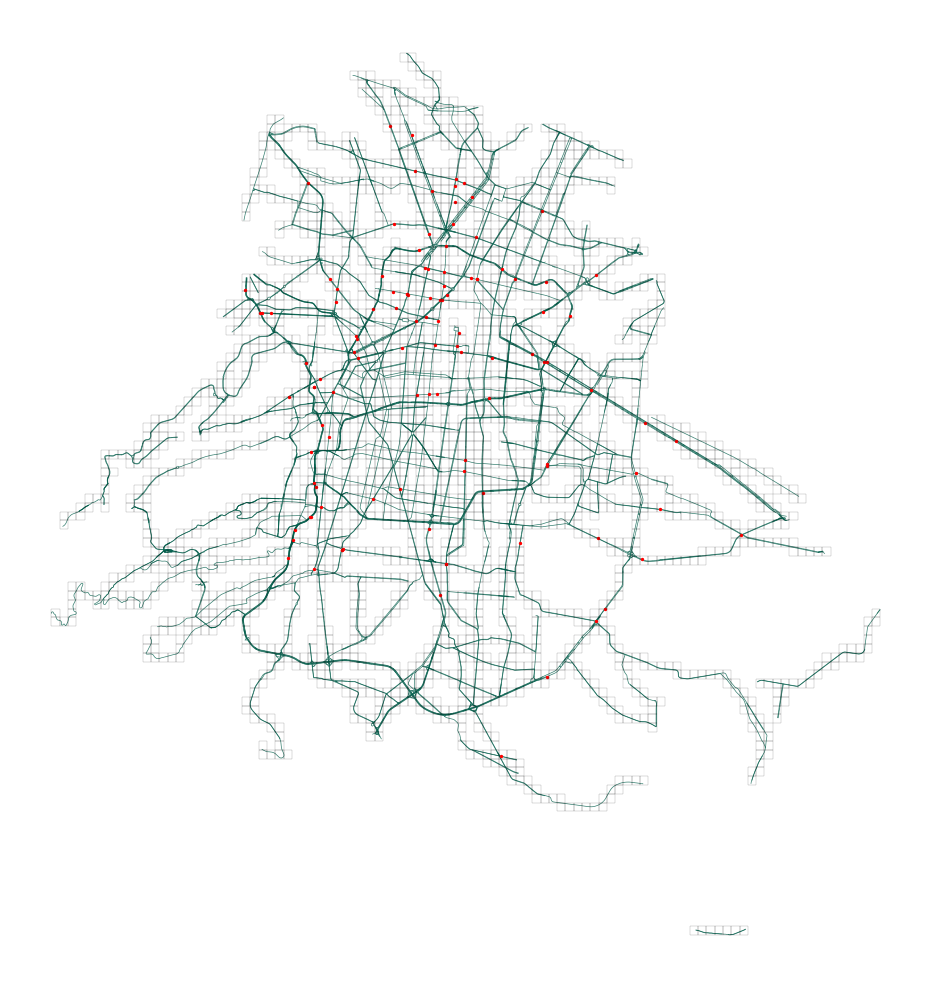

In [13]:
# Sacamos el grid
grid_size = 100
grid = build_grid(ejes, grid_size)

# Hacemos el plot solo con los datos pedidos
fig, ax = plt.subplots(figsize=(10,10))

ax.axis('off')

ejes.plot(ax=ax, zorder=1, linewidth=.5, color='#005D4A', alpha=.8)
cameras_gdf.plot(ax=ax, color='red', markersize=2, zorder=2)
grid.boundary.plot(ax=ax, linewidth=.1, color='black')

# Vamos a ver de esos cuántas vialidades tiene cada uno
n_intersecciones = get_grid_features(ejes, grid)
# grid.merge(n_intersecciones).query('total_vialidades > 2').centroid.plot(ax=ax, markersize=3, color='#99d98c')

fig.tight_layout()

save = True
if save: fig.savefig(fname=os.path.join(path_data, 'images', f'grid_{grid_size}.png'), dpi=450, transparent=True)
    
plt.show()